# Homo Sapiens Analysis Graphs — Local Version

Local adaptation of `analysis_graphs-homo_sapiens.ipynb`.  
Reads pre-computed `.pkl` result files from `analysis/results/homo_sapiens/`  
and produces a publication-ready composite SVG figure (panels A–D).

In [1]:
import os
import sys
import json
import typing

import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scipy.stats as stats
import seaborn as sns
from matplotlib.gridspec import GridSpec
from pathlib import Path

# Make sure project root is on path
project_root = str(Path(os.getcwd()))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print(f"Working directory: {project_root}")

Working directory: /Users/shimka/PycharmProjects/Igem_TAU_2021


In [2]:
# ── Global font settings ───────────────────────────────────────────────────
BASE_FONT   = 24
TITLE_FONT  = 28
LABEL_FONT  = 24
TICK_FONT   = 21
PANEL_FONT  = 30
ANNOT_FONT  = 21
LEGEND_FONT = 20

plt.rcParams.update({
    "font.size":             BASE_FONT,
    "axes.titlesize":        TITLE_FONT,
    "axes.labelsize":        LABEL_FONT,
    "xtick.labelsize":       TICK_FONT,
    "ytick.labelsize":       TICK_FONT,
    "legend.fontsize":       LEGEND_FONT,
    "legend.title_fontsize": LEGEND_FONT,
    "figure.titlesize":      TITLE_FONT,
    "font.weight":           "bold",
})
sns.set(style="whitegrid", context="talk",
        rc={
            "font.size":        BASE_FONT,
            "axes.titlesize":   TITLE_FONT,
            "axes.labelsize":   LABEL_FONT,
            "xtick.labelsize":  TICK_FONT,
            "ytick.labelsize":  TICK_FONT,
        })
print("Font settings applied.")

Font settings applied.


In [3]:
# ── Paths ──────────────────────────────────────────────────────────────────
RESULTS_DIR  = Path(project_root) / "analysis" / "results" / "homo_sapiens"
FIGURES_DIR  = RESULTS_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PKL_ECOLI_WANTED    = RESULTS_DIR / "ecoli_wanted_bacillus_unwanted.pkl"
PKL_BACILLUS_WANTED = RESULTS_DIR / "ecoli_uwanted_bacillus_wanted.pkl"

assert PKL_ECOLI_WANTED.exists(),    f"Missing: {PKL_ECOLI_WANTED}"
assert PKL_BACILLUS_WANTED.exists(), f"Missing: {PKL_BACILLUS_WANTED}"

print("Result files found:")
print(f"  {PKL_ECOLI_WANTED}")
print(f"  {PKL_BACILLUS_WANTED}")
print(f"SVG figures will be saved to: {FIGURES_DIR}")

Result files found:
  /Users/shimka/PycharmProjects/Igem_TAU_2021/analysis/results/homo_sapiens/ecoli_wanted_bacillus_unwanted.pkl
  /Users/shimka/PycharmProjects/Igem_TAU_2021/analysis/results/homo_sapiens/ecoli_uwanted_bacillus_wanted.pkl
SVG figures will be saved to: /Users/shimka/PycharmProjects/Igem_TAU_2021/analysis/results/homo_sapiens/figures


In [4]:
# ── Variant definitions ────────────────────────────────────────────────────
variant_names = [
    "single_diff",
    "zscore_single_diff",
    "zscore_bulk_diff",
    "single_ratio",
    "zscore_single_ratio",
    "zscore_bulk_ratio",
    "single_wanted_organism",
]

label_map = {
    "single_diff":           "single_diff",
    "zscore_single_diff":    "zscore_single_diff",
    "zscore_bulk_diff":      "zscore_bulk_diff",
    "single_ratio":          "single_ratio",
    "zscore_single_ratio":   "zscore_single_ratio",
    "zscore_bulk_ratio":     "zscore_bulk_ratio",
    "single_wanted_organism": "wanted_baseline",
}

print("Variants:", variant_names)

Variants: ['single_diff', 'zscore_single_diff', 'zscore_bulk_diff', 'single_ratio', 'zscore_single_ratio', 'zscore_bulk_ratio', 'single_wanted_organism']


In [5]:
# ── Load data: E.coli wanted / Bacillus unwanted ───────────────────────────
result_ew = pd.read_pickle(PKL_ECOLI_WANTED)
print(f"E.coli wanted dataset: {result_ew.shape[0]:,} genes × {result_ew.shape[1]} columns")
result_ew.head(2)

E.coli wanted dataset: 20,146 genes × 89 columns


,gene_name,sequence,db_xref,protein,protein_id,location,gbkey,exception,transl_except,partial,...,final_optimization_score_single_wanted_organism,average_distance_score_single_wanted_organism,average_distance_non_normalized_score_single_wanted_organism,weakest_link_score_single_wanted_organism,ratio_score_single_wanted_organism,orf_optimization_cub_index_single_wanted_organism,evaluation_score_single_wanted_organism,run_time_single_wanted_organism,iterations_count_single_wanted_organism,final_sequence_single_wanted_organism
0,A1BG,ATGTCCATGCTCGTGGTCTTTCTCTTGCTGTGGGGTGTCACCTGGG...,"CCDS:CCDS12976.1,Ensembl:ENSP00000263100.2,Gen...",alpha-1B-glycoprotein precursor,NP_570602.2,"complement(join(58347022..58347029,58347353..5...",CDS,NaN,NaN,NaN,...,None,-0.489155,0.111127,-0.489155,0.960409,CAI,average_distance,0.000852,1,ATGTCCATGCTCGTGGTCTTTCTCTTGCTGTGGGGTGTCACCTGGG...
1,A1CF,ATGGAAGCAGTGTGTCTGGGCACATGCCCAGAGCCAGAAGCGAGCA...,GeneID:29974,APOBEC1 complementation factor isoform X1,XP_047281083.1,"complement(join(50806729..50806880,50809894..5...",CDS,NaN,NaN,NaN,...,None,0.964279,0.193275,0.964279,1.076180,CAI,average_distance,0.000952,1,ATGGAAGCAGTGTGTCTGGGCACATGCCCAGAGCCAGAAGCGAGCA...


Saved: /Users/shimka/PycharmProjects/Igem_TAU_2021/analysis/results/homo_sapiens/figures/homo_sapiens_ecoli_wanted_bacillus_unwanted.svg


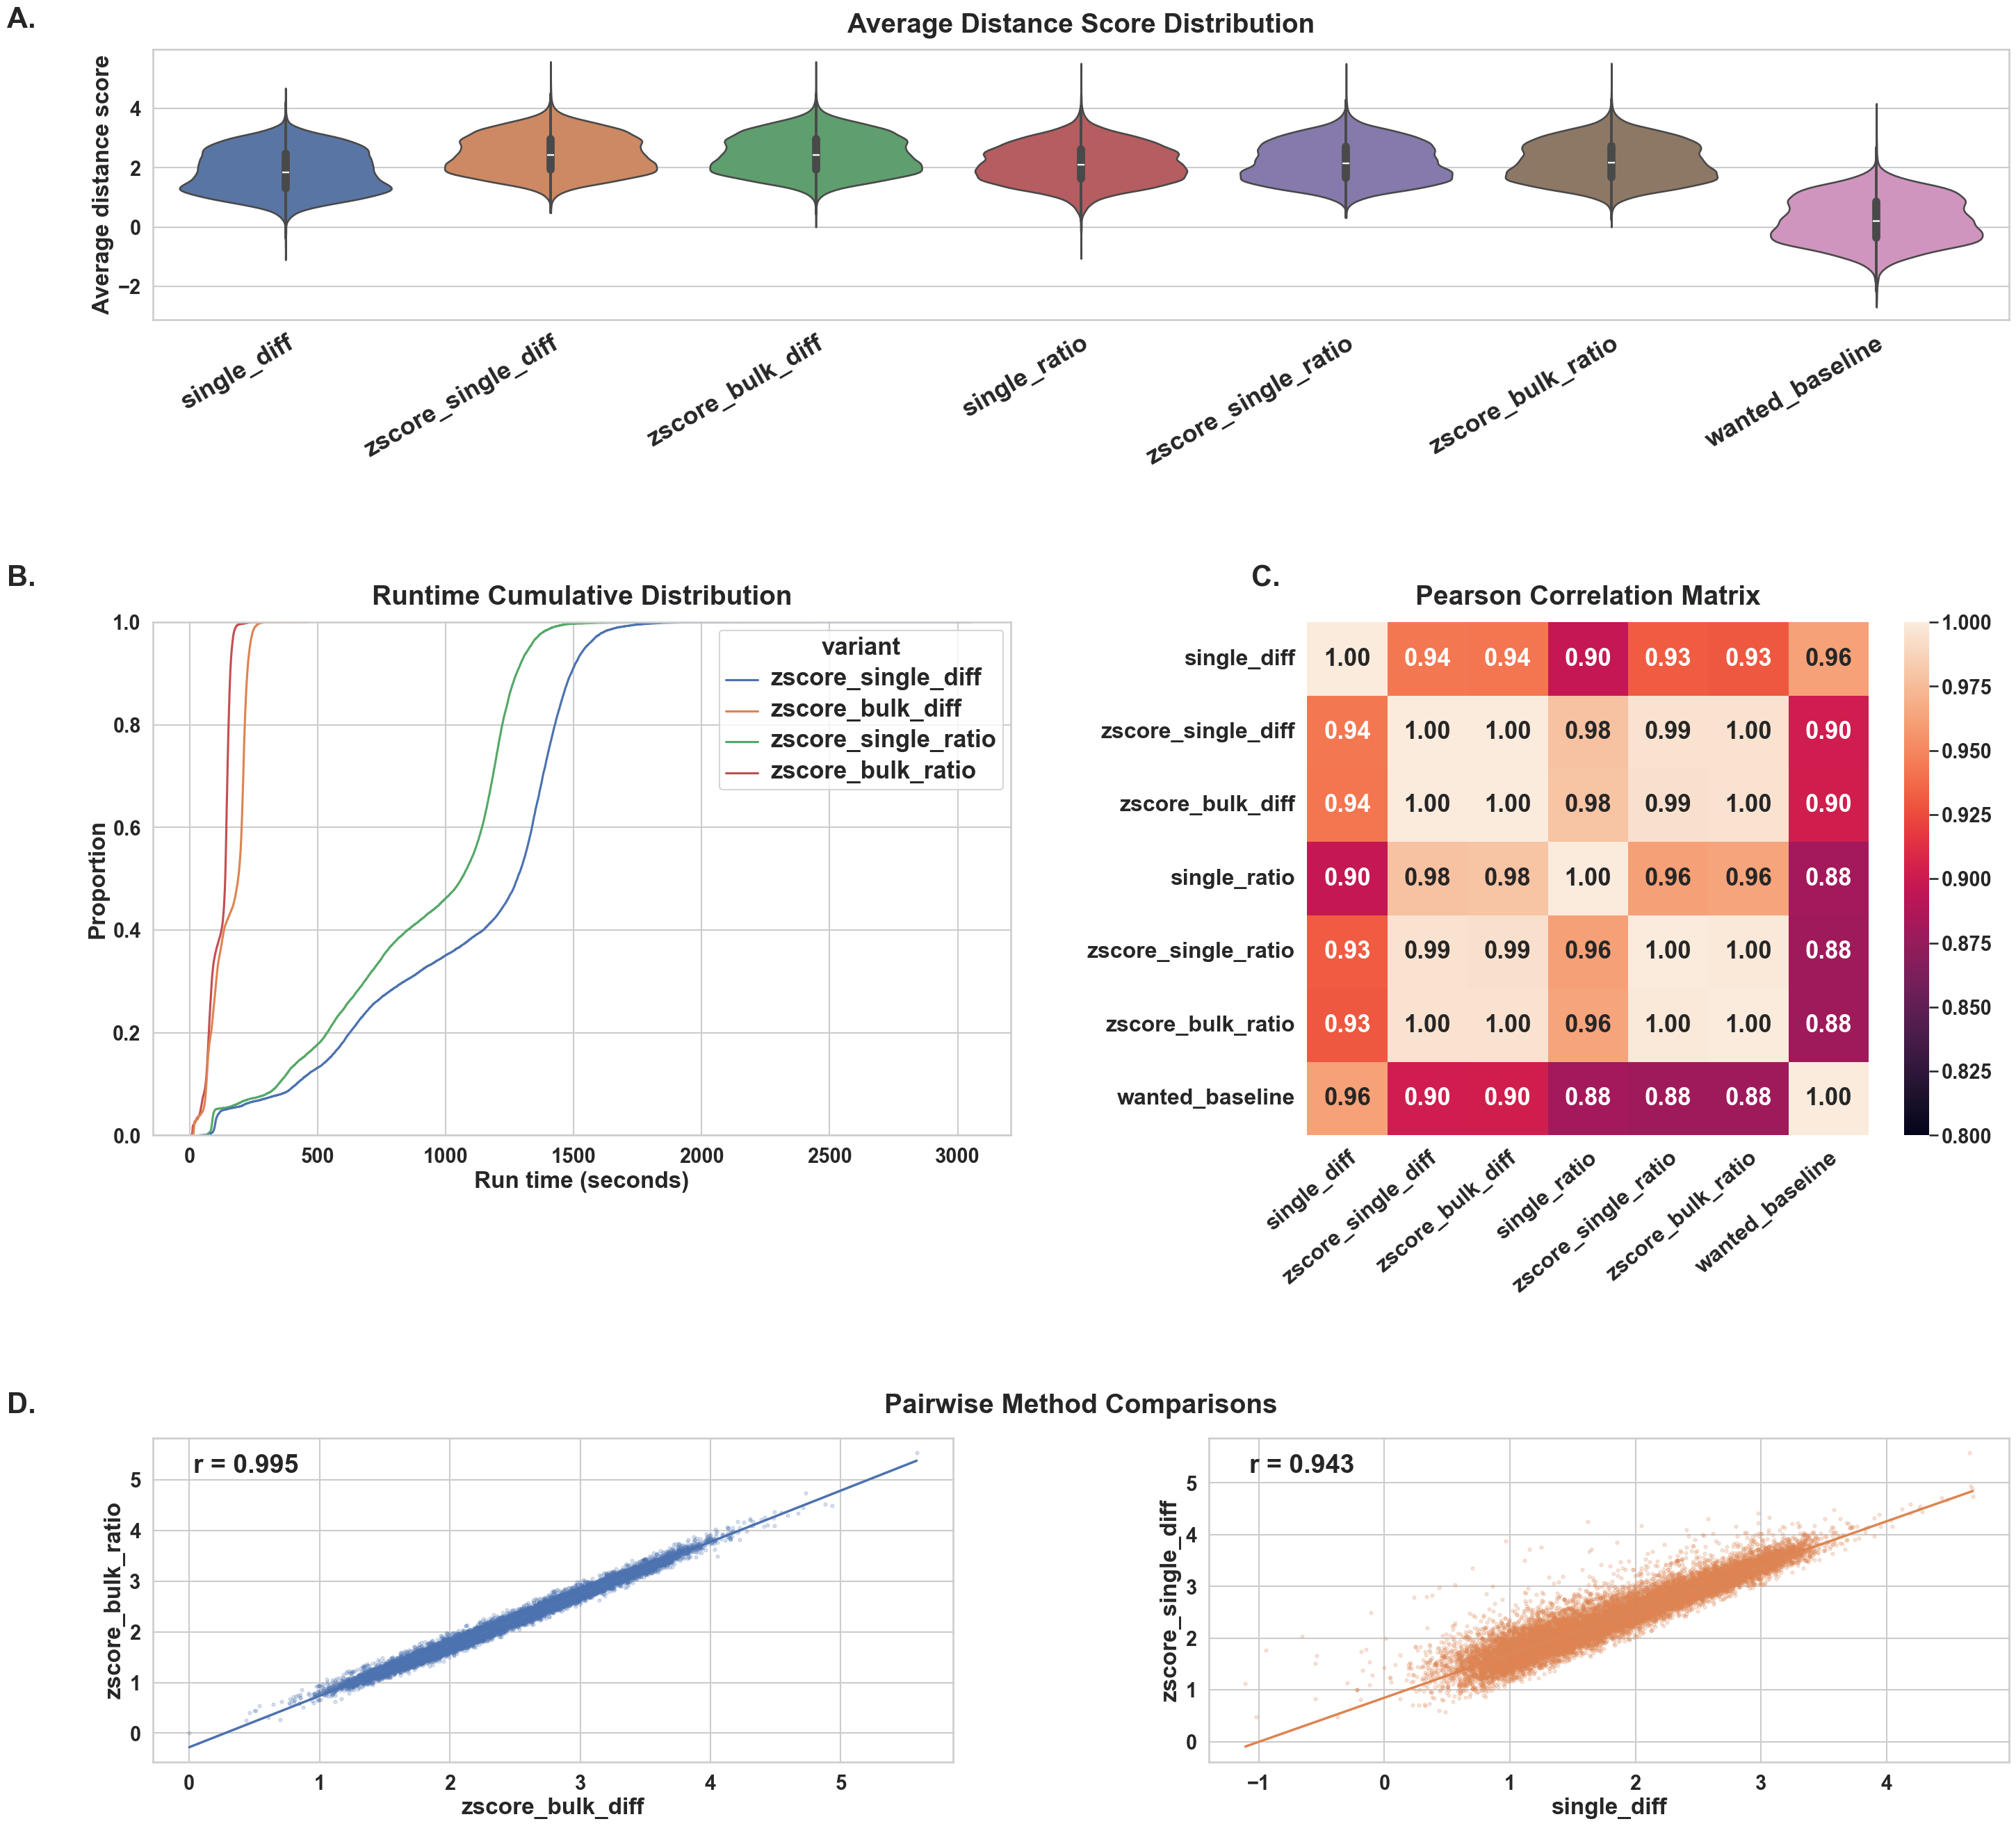

In [6]:
from matplotlib.transforms import blended_transform_factory

FIG_LEFT_X = 0.01

def panel_label(fig, ax, label, y=1.06):
    tr = blended_transform_factory(fig.transFigure, ax.transAxes)
    ax.text(FIG_LEFT_X, y, label, transform=tr,
            fontsize=PANEL_FONT, fontweight="bold", va="bottom", clip_on=False)

def panel_label_axes(ax, label, x=-0.10, y=1.06):
    ax.text(x, y, label, transform=ax.transAxes,
            fontsize=PANEL_FONT, fontweight="bold", va="bottom", clip_on=False)


def make_combined_figure(df: pd.DataFrame, svg_stem: str):

    avg_cols = [
        f"average_distance_score_{v}"
        for v in variant_names
        if f"average_distance_score_{v}" in df.columns
    ]
    run_time_cols = [
        f"run_time_{v}"
        for v in variant_names
        if f"run_time_{v}" in df.columns and "zscore" in v
    ]

    fig = plt.figure(figsize=(30, 28))
    gs = GridSpec(
        3, 2,
        figure=fig,
        height_ratios=[1.0, 1.9, 1.2],
        width_ratios=[1.1, 0.9],
        hspace=0.82,
        wspace=0.38,
    )

    # ── A: violin (full width) ────────────────────────────────────────────
    axA = fig.add_subplot(gs[0, :])
    violin_data = df[avg_cols].copy()
    violin_data.columns = [
        label_map[c.removeprefix("average_distance_score_")] for c in avg_cols
    ]
    sns.violinplot(data=violin_data, cut=0, inner="box", ax=axA)
    axA.set_ylabel("Average distance score", fontsize=LABEL_FONT, fontweight="bold")
    axA.set_xlabel("")
    plt.setp(axA.get_xticklabels(), rotation=30, ha="right",
             rotation_mode="anchor", fontweight="bold", fontsize=TICK_FONT + 5)
    axA.tick_params(axis="y", labelsize=TICK_FONT)
    axA.set_title("Average Distance Score Distribution",
                  fontsize=TITLE_FONT, fontweight="bold", pad=18)
    panel_label(fig, axA, "A.")

    # ── B: ECDF (left col, row 1) ─────────────────────────────────────────
    axB = fig.add_subplot(gs[1, 0])
    if run_time_cols:
        run_df = df[run_time_cols].copy()
        run_df.columns = [c.removeprefix("run_time_") for c in run_df.columns]
        run_long = run_df.melt(var_name="variant", value_name="runtime").dropna()
        sns.ecdfplot(data=run_long, x="runtime", hue="variant", ax=axB)
        leg = axB.get_legend()
        if leg is not None:
            leg.get_title().set_fontweight("bold")
            leg.get_title().set_fontsize(LEGEND_FONT + 5)
            for txt in leg.get_texts():
                txt.set_fontweight("bold")
                txt.set_fontsize(LEGEND_FONT + 5)
    axB.set_xlabel("Run time (seconds)", fontsize=LABEL_FONT, fontweight="bold")
    axB.set_ylabel("Proportion", fontsize=LABEL_FONT, fontweight="bold")
    axB.tick_params(axis="both", labelsize=TICK_FONT)
    axB.set_title("Runtime Cumulative Distribution",
                  fontsize=TITLE_FONT, fontweight="bold", pad=18)
    panel_label(fig, axB, "B.")

    # ── C: heatmap (right col, row 1) ─────────────────────────────────────
    axC = fig.add_subplot(gs[1, 1])
    corr = df[avg_cols].corr(method="pearson")
    corr.index   = [label_map[c.removeprefix("average_distance_score_")] for c in corr.index]
    corr.columns = [label_map[c.removeprefix("average_distance_score_")] for c in corr.columns]
    sns.heatmap(corr, cmap="rocket", vmin=0.8, vmax=1.0,
                annot=True, fmt=".2f",
                annot_kws={"size": ANNOT_FONT + 4, "weight": "bold"},
                ax=axC, cbar=True)
    plt.setp(axC.get_xticklabels(), rotation=40, ha="right",
             rotation_mode="anchor", fontweight="bold", fontsize=TICK_FONT + 2)
    plt.setp(axC.get_yticklabels(), rotation=0, fontweight="bold", fontsize=TICK_FONT + 2)
    axC.set_title("Pearson Correlation Matrix",
                  fontsize=TITLE_FONT, fontweight="bold", pad=18)
    panel_label_axes(axC, "C.")

    # ── D: two scatters side by side at the bottom ────────────────────────
    axD_ghost = fig.add_subplot(gs[2, :], frameon=False)
    axD_ghost.set_xticks([])
    axD_ghost.set_yticks([])
    for sp in axD_ghost.spines.values():
        sp.set_visible(False)
    panel_label(fig, axD_ghost, "D.")
    axD_ghost.text(0.50, 1.06, "Pairwise Method Comparisons",
                   transform=axD_ghost.transAxes,
                   fontsize=TITLE_FONT, fontweight="bold",
                   ha="center", va="bottom")

    subgs_d = gs[2, :].subgridspec(1, 2, wspace=0.32)
    d_pairs = [
        ("average_distance_score_zscore_bulk_diff",
         "average_distance_score_zscore_bulk_ratio"),
        ("average_distance_score_single_diff",
         "average_distance_score_zscore_single_diff"),
    ]
    d_pairs = [(x, y) for x, y in d_pairs if x in df.columns and y in df.columns]

    palette = sns.color_palette("deep")
    for idx, (xcol, ycol) in enumerate(d_pairs):
        ax = fig.add_subplot(subgs_d[0, idx])
        plot_df = df[[xcol, ycol]].dropna()
        sns.regplot(data=plot_df, x=xcol, y=ycol, ax=ax,
                    scatter_kws={"s": 12, "alpha": 0.22},
                    line_kws={"lw": 2.5},
                    color=palette[idx])
        r, _ = stats.pearsonr(plot_df[xcol], plot_df[ycol])
        ax.set_xlabel(xcol.removeprefix("average_distance_score_"),
                      fontsize=LABEL_FONT, fontweight="bold")
        ax.set_ylabel(ycol.removeprefix("average_distance_score_"),
                      fontsize=LABEL_FONT, fontweight="bold")
        ax.tick_params(axis="both", labelsize=TICK_FONT)
        ax.text(0.05, 0.95, f"r = {r:.3f}", transform=ax.transAxes,
                va="top", fontsize=ANNOT_FONT + 6, fontweight="bold")

    fig.subplots_adjust(top=0.94, bottom=0.06, left=0.08, right=0.97)

    svg_path = FIGURES_DIR / f"{svg_stem}.svg"
    fig.savefig(svg_path, format="svg", bbox_inches="tight")
    print(f"Saved: {svg_path}")
    plt.show()
    plt.close(fig)
    return svg_path


svg_ew = make_combined_figure(
    result_ew,
    svg_stem="homo_sapiens_ecoli_wanted_bacillus_unwanted",
)

Saved: /Users/shimka/PycharmProjects/Igem_TAU_2021/analysis/results/homo_sapiens/figures/homo_sapiens_ecoli_wanted_bacillus_unwanted_v2.svg


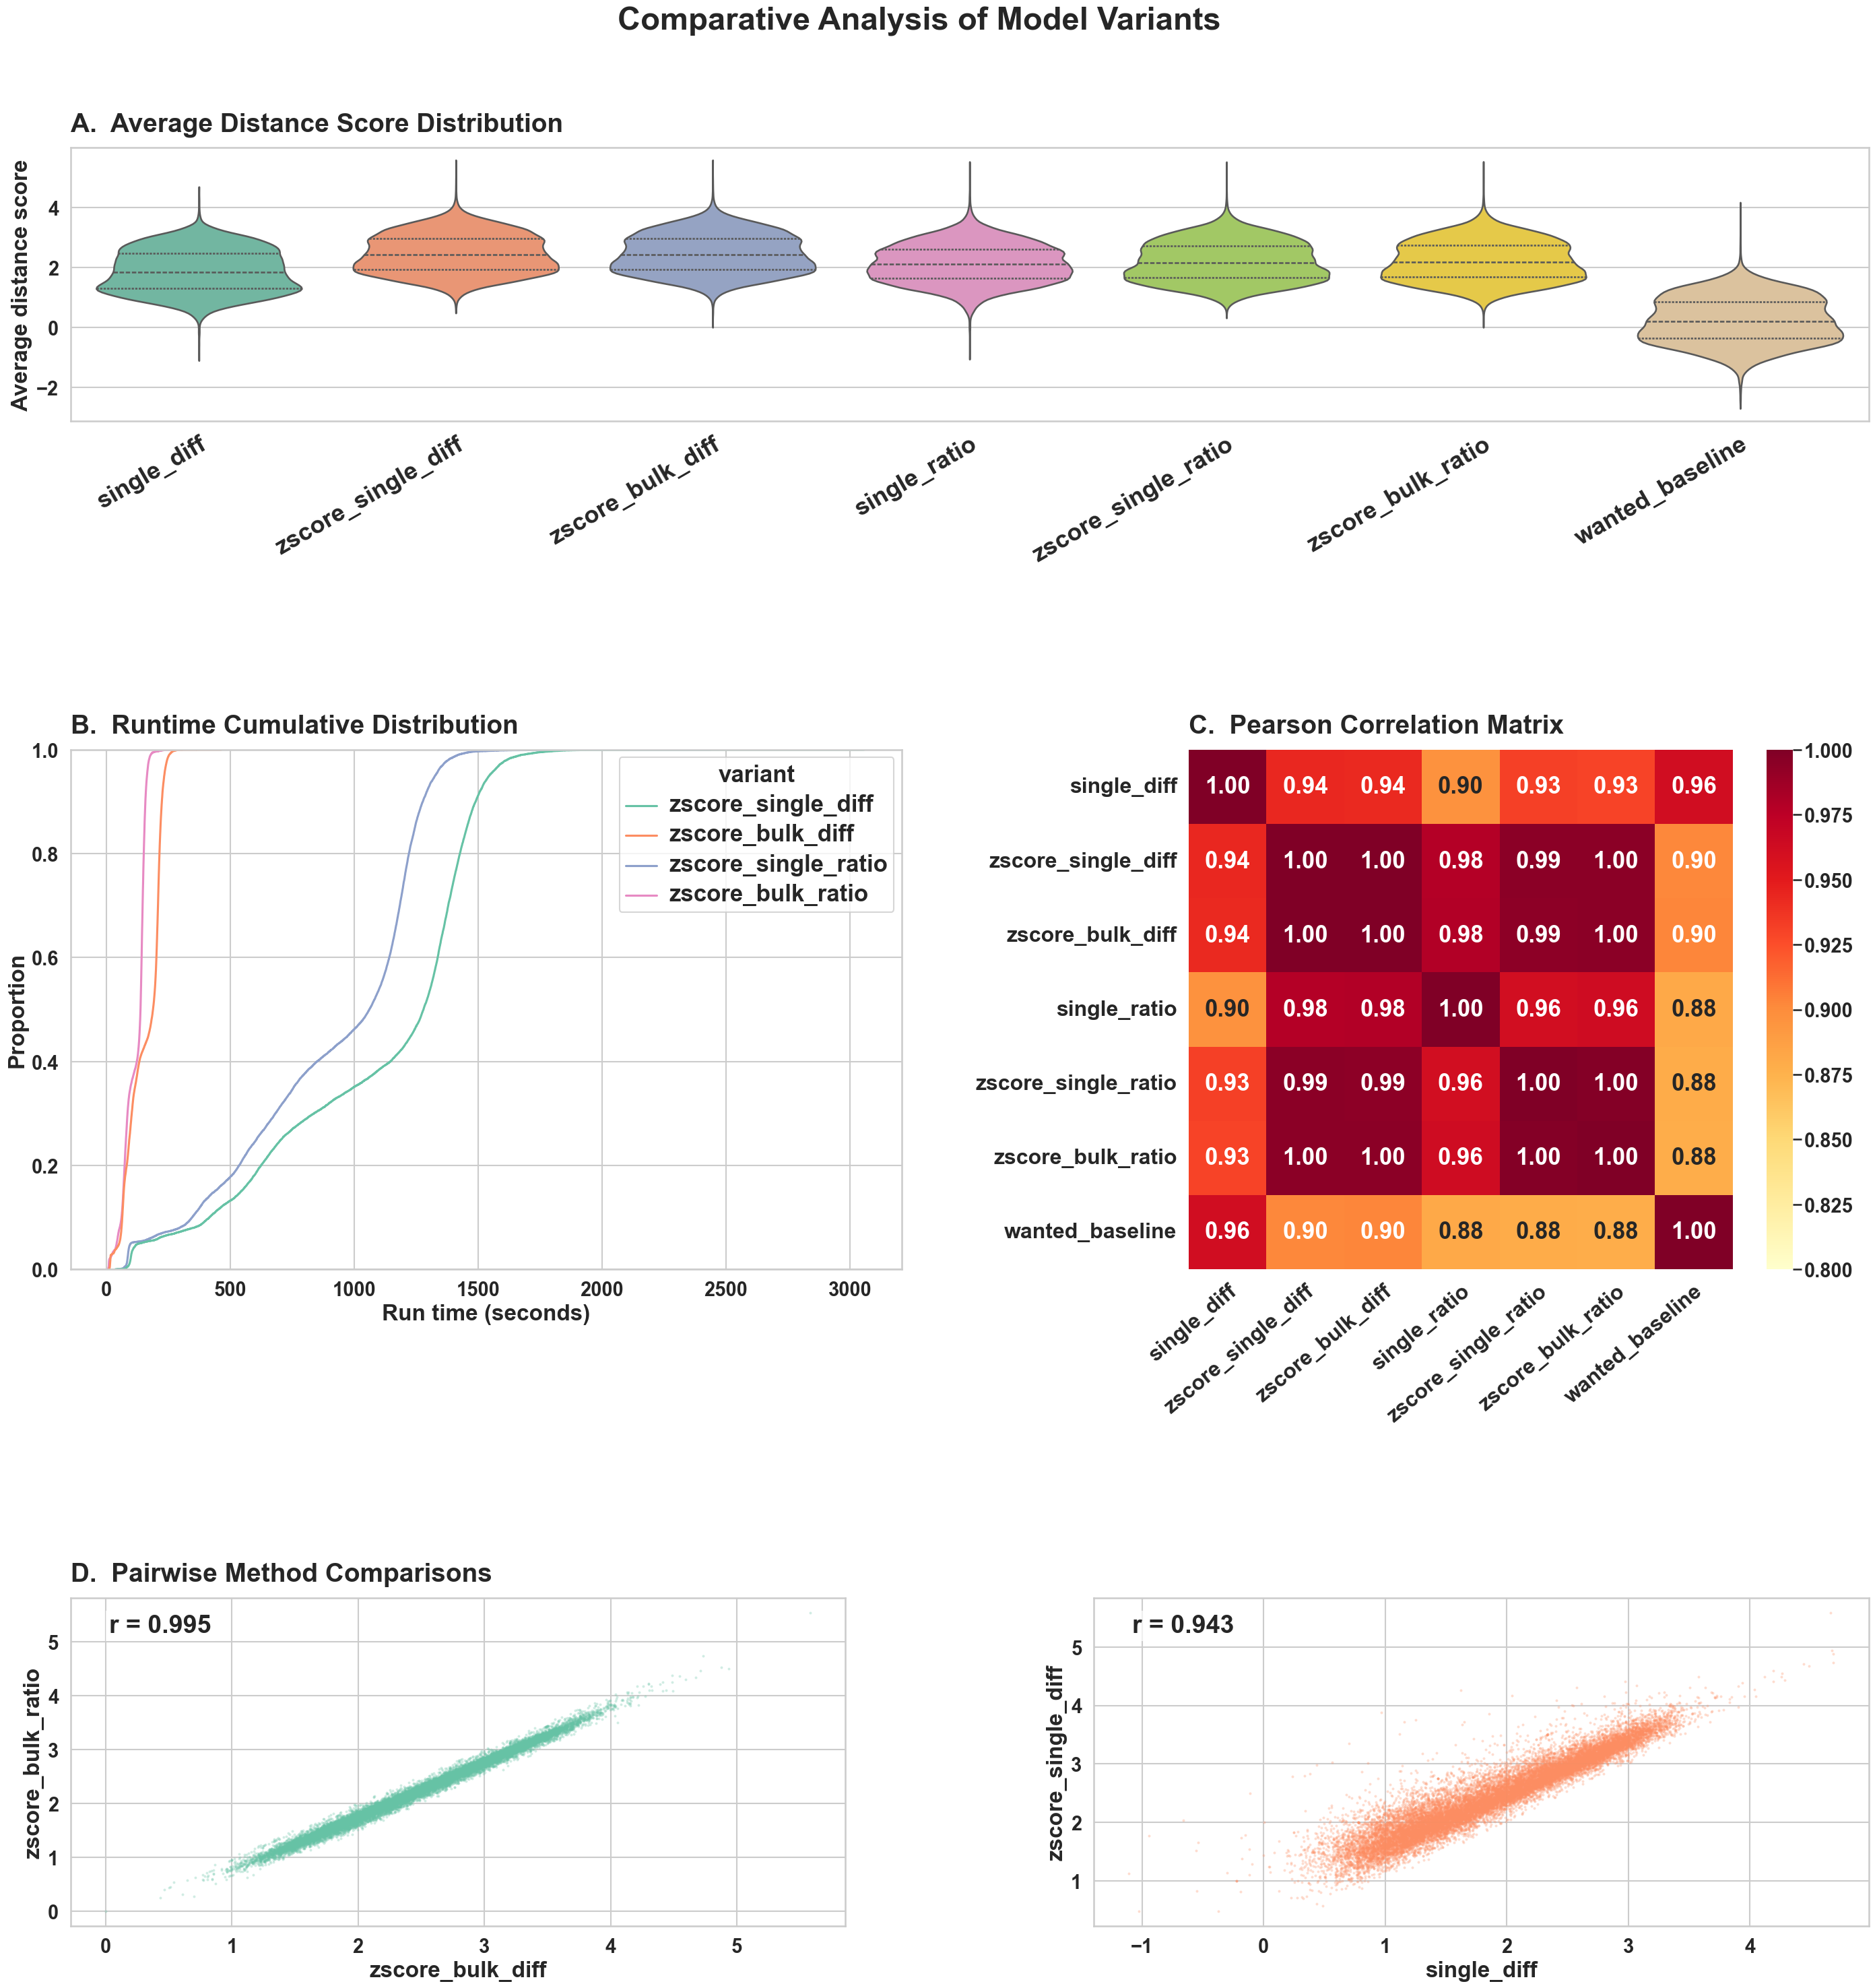

In [7]:

# ── Improved combined figure (v2) ─────────────────────────────────────────
from scipy.stats import pearsonr as _pearsonr

_PALETTE = "Set2"
_HEATMAP_CMAP = "YlOrRd"


def make_combined_figure_v2(df: pd.DataFrame, svg_stem: str):
    avg_cols = [
        f"average_distance_score_{v}"
        for v in variant_names
        if f"average_distance_score_{v}" in df.columns
    ]
    run_time_cols = [
        f"run_time_{v}"
        for v in variant_names
        if f"run_time_{v}" in df.columns and "zscore" in v
    ]

    fig = plt.figure(figsize=(30, 30))

    fig.suptitle(
        "Comparative Analysis of Model Variants",
        fontsize=TITLE_FONT + 6,
        fontweight="bold",
        y=1.01,
    )

    gs = GridSpec(
        3, 2,
        figure=fig,
        height_ratios=[1.0, 1.9, 1.2],
        width_ratios=[1.1, 0.9],
        hspace=0.88,
        wspace=0.38,
    )

    # ── A: violin ─────────────────────────────────────────────────────────
    axA = fig.add_subplot(gs[0, :])
    violin_data = df[avg_cols].copy()
    violin_data.columns = [
        label_map[c.removeprefix("average_distance_score_")] for c in avg_cols
    ]
    sns.violinplot(
        data=violin_data, cut=0, inner="quart",
        palette=_PALETTE, ax=axA,
    )
    axA.set_ylabel("Average distance score", fontsize=LABEL_FONT, fontweight="bold")
    axA.set_xlabel("")
    plt.setp(axA.get_xticklabels(), rotation=30, ha="right",
             rotation_mode="anchor", fontweight="bold", fontsize=TICK_FONT + 5)
    axA.tick_params(axis="y", labelsize=TICK_FONT)
    axA.set_title("A.  Average Distance Score Distribution",
                  fontsize=TITLE_FONT, fontweight="bold", pad=18, loc="left")

    # ── B: ECDF ───────────────────────────────────────────────────────────
    axB = fig.add_subplot(gs[1, 0])
    if run_time_cols:
        run_df = df[run_time_cols].copy()
        run_df.columns = [c.removeprefix("run_time_") for c in run_df.columns]
        run_long = run_df.melt(var_name="variant", value_name="runtime").dropna()
        sns.ecdfplot(data=run_long, x="runtime", hue="variant",
                     palette=_PALETTE, ax=axB)
        leg = axB.get_legend()
        if leg is not None:
            leg.get_title().set_fontweight("bold")
            leg.get_title().set_fontsize(LEGEND_FONT + 5)
            for txt in leg.get_texts():
                txt.set_fontweight("bold")
                txt.set_fontsize(LEGEND_FONT + 5)
    axB.set_xlabel("Run time (seconds)", fontsize=LABEL_FONT, fontweight="bold")
    axB.set_ylabel("Proportion", fontsize=LABEL_FONT, fontweight="bold")
    axB.tick_params(axis="both", labelsize=TICK_FONT)
    axB.set_title("B.  Runtime Cumulative Distribution",
                  fontsize=TITLE_FONT, fontweight="bold", pad=18, loc="left")

    # ── C: Pearson heatmap ────────────────────────────────────────────────
    axC = fig.add_subplot(gs[1, 1])
    corr = df[avg_cols].corr(method="pearson")
    corr.index   = [label_map[c.removeprefix("average_distance_score_")] for c in corr.index]
    corr.columns = [label_map[c.removeprefix("average_distance_score_")] for c in corr.columns]
    sns.heatmap(
        corr, cmap=_HEATMAP_CMAP, vmin=0.8, vmax=1.0,
        annot=True, fmt=".2f",
        annot_kws={"size": ANNOT_FONT + 4, "weight": "bold"},
        ax=axC, cbar=True,
    )
    plt.setp(axC.get_xticklabels(), rotation=40, ha="right",
             rotation_mode="anchor", fontweight="bold", fontsize=TICK_FONT + 2)
    plt.setp(axC.get_yticklabels(), rotation=0, fontweight="bold", fontsize=TICK_FONT + 2)
    axC.set_title("C.  Pearson Correlation Matrix",
                  fontsize=TITLE_FONT, fontweight="bold", pad=18, loc="left")

    # ── D: scatter plots ──────────────────────────────────────────────────
    d_pairs = [
        ("average_distance_score_zscore_bulk_diff",
         "average_distance_score_zscore_bulk_ratio"),
        ("average_distance_score_single_diff",
         "average_distance_score_zscore_single_diff"),
    ]
    d_pairs = [(x, y) for x, y in d_pairs if x in df.columns and y in df.columns]

    axD_ghost = fig.add_subplot(gs[2, :], frameon=False)
    axD_ghost.set_xticks([])
    axD_ghost.set_yticks([])
    for sp in axD_ghost.spines.values():
        sp.set_visible(False)
    axD_ghost.set_title("D.  Pairwise Method Comparisons",
                        fontsize=TITLE_FONT, fontweight="bold", pad=18, loc="left")

    subgs_d = gs[2, :].subgridspec(1, len(d_pairs), wspace=0.32)
    palette = sns.color_palette(_PALETTE)
    for idx, (xcol, ycol) in enumerate(d_pairs):
        ax = fig.add_subplot(subgs_d[0, idx])
        plot_df = df[[xcol, ycol]].dropna()

        sns.scatterplot(
            data=plot_df, x=xcol, y=ycol,
            color=palette[idx], s=8, alpha=0.3, linewidth=0,
            ax=ax,
        )

        r, _ = _pearsonr(plot_df[xcol], plot_df[ycol])
        ax.set_xlabel(xcol.removeprefix("average_distance_score_"),
                      fontsize=LABEL_FONT, fontweight="bold")
        ax.set_ylabel(ycol.removeprefix("average_distance_score_"),
                      fontsize=LABEL_FONT, fontweight="bold")
        ax.tick_params(axis="both", labelsize=TICK_FONT)
        ax.text(0.05, 0.95, f"r = {r:.3f}", transform=ax.transAxes,
                va="top", fontsize=ANNOT_FONT + 6, fontweight="bold",
                bbox=dict(facecolor="white", alpha=0.7, edgecolor="none"))

    fig.subplots_adjust(top=0.94, bottom=0.06, left=0.08, right=0.97)

    svg_path = FIGURES_DIR / f"{svg_stem}_v2.svg"
    fig.savefig(svg_path, format="svg", bbox_inches="tight")
    print(f"Saved: {svg_path}")
    plt.show()
    plt.close(fig)
    return svg_path


svg_ew_v2 = make_combined_figure_v2(
    result_ew,
    svg_stem="homo_sapiens_ecoli_wanted_bacillus_unwanted",
)


In [8]:
# ── Bacillus wanted figure — uncomment to generate ────────────────────────
# result_bw = pd.read_pickle(PKL_BACILLUS_WANTED)
# print(f"Bacillus wanted dataset: {result_bw.shape[0]:,} genes × {result_bw.shape[1]} columns")

In [9]:
# ── Bacillus wanted figure — uncomment to generate ────────────────────────
# svg_bw = make_combined_figure(
#     result_bw,
#     svg_stem="homo_sapiens_ecoli_unwanted_bacillus_wanted",
# )

In [10]:
print("SVG figures written to:")
for p in sorted(FIGURES_DIR.glob("*.svg")):
    print(f"  {p}")

SVG figures written to:
  /Users/shimka/PycharmProjects/Igem_TAU_2021/analysis/results/homo_sapiens/figures/homo_sapiens_ecoli_unwanted_bacillus_wanted.svg
  /Users/shimka/PycharmProjects/Igem_TAU_2021/analysis/results/homo_sapiens/figures/homo_sapiens_ecoli_wanted_bacillus_unwanted.svg
  /Users/shimka/PycharmProjects/Igem_TAU_2021/analysis/results/homo_sapiens/figures/homo_sapiens_ecoli_wanted_bacillus_unwanted_v2.svg
